# Sequence Data

In this notebook, we explore the sequence data collected for modelling TCR:pMHC interactions.

In [1]:
import itertools
import re
import warnings

import logomaker
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import openchord
import pandas as pd
import plotly.graph_objects as go
import seaborn as sns
import upsetplot
from matplotlib.patches import Patch
from pyxdameraulevenshtein import damerau_levenshtein_distance

## Data selection pipeline

In [2]:
with open('data/logs/collate_sequence_data.log', 'r') as fh:
    logs = fh.read()

lines = logs.split('\n')

In [3]:
count_lines = [
    (
        i,
        (
            re.search(r'INFO: Number of (.*?): (\d+)$', line)[1],
            int(re.search(r'INFO: Number of (.*?): (\d+)$', line)[2]),
        ),
    )
    for i, line in enumerate(lines)
    if re.search(r'INFO: (.*?): (\d+)$', line)
]

steps = [lines[i - 1].split('INFO: ')[-1] for i, _ in count_lines]

In [4]:
chunks = []
current_chunk = None

for i, line in enumerate(steps):
    if line.startswith(('Processing', 'Collating')):
        if current_chunk is None:
            current_chunk = []

        else:
            chunks.append(current_chunk)
            current_chunk = []

    current_chunk.append((i, line))

chunks.append(current_chunk)

sources = []
targets = []
counts = []

for chunk in chunks[:-1]:
    for (idx1, _), (idx2, _) in itertools.pairwise(chunk):
        source, prev_count = count_lines[idx1][1]
        target, count = count_lines[idx2][1]

        sources.append(source)
        targets.append(target)
        counts.append(count)

        sources.append(source)
        targets.append('reject')
        counts.append(prev_count - count)

    source, count = count_lines[chunk[-1][0]][1]
    target, _ = count_lines[chunks[-1][0][0]][1]

    sources.append(source)
    targets.append(target)
    counts.append(count)


for (idx1, _), (idx2, _) in itertools.pairwise(chunks[-1]):
    source, prev_count = count_lines[idx1][1]
    target, count = count_lines[idx2][1]

    sources.append(source)
    targets.append(target)
    counts.append(count)

    sources.append(source)
    targets.append('reject')
    counts.append(prev_count - count)

selection_df = pd.DataFrame(
    {
        'source': sources,
        'target': targets,
        'count': counts,
    }
)

In [5]:
plot_df = selection_df.copy()

unique_source_target = list(np.unique(plot_df[['source', 'target']].to_numpy().flatten()))

mapping_dict = {k: v for v, k in enumerate(unique_source_target)}

plot_df['source'] = plot_df['source'].map(mapping_dict)
plot_df['target'] = plot_df['target'].map(mapping_dict)

fig = go.Figure(
    data=[
        go.Sankey(
            node={
                'pad': 15,
                'thickness': 20,
                'line': {'color': 'black', 'width': 0.5},
                'label': unique_source_target,
            },
            link={
                'source': plot_df['source'],
                'target': plot_df['target'],
                'value': plot_df['count'],
            },
        )
    ]
)

fig.update_layout(title_text='Sankey diagram of sequence data curation', font_size=10, width=1000, height=600)
fig.show()

## Data visualisations

In [6]:
sequence_data = pd.read_csv('data/interim/sequences.csv')
sequence_data

,cdr1_alpha,cdr2_alpha,cdr3_alpha,cdr1_beta,cdr2_beta,cdr3_beta,peptide,mhc_pseudo,v_alpha,j_alpha,v_beta,j_beta,mhc1,mhc2,mhc_type,species,source
0,ASGYPA,ASRDKEK,ALAPPDKLT,SGHSN,HYEKVE,ASSVPGQGDTGQLY,HGIRNASFI,REQKKGQQWRVRKSGAEHYAYEGEEW,TRAV6N-7*01,TRAJ11*01,TRBV12-1*01,TRBJ2-2*01,MH2-D1,B2M,MH1,Mouse,VDJdb
1,ASGYPA,ASRDKEK,ALAPPDKLT,SGHSN,HYEKVE,ASSVPGQGDTGQLY,HGIRNASFI,RERRKGNQSRVRKAGAERDAYEGEEW,TRAV6N-7*01,TRAJ11*01,TRBV12-1*01,TRBJ2-2*01,MH2-D1,B2M,MH1,Mouse,VDJdb
2,ASGYPA,ASRDKEK,ALGAQGGRALI,MSHET,SYDVDS,ASSHDRGQLY,SSLENFRAYV,REQKKGQQWRVRKSGAEHYAYEGEEW,TRAV6N-7*01,TRAJ15*01,TRBV29*01,TRBJ2-2*01,MH2-D1,B2M,MH1,Mouse,VDJdb
3,ASGYPA,ASRDKEK,ALGAQGGRALI,MSHET,SYDVDS,ASSHDRGQLY,SSLENFRAYV,RERRKGNQSRVRKAGAERDAYEGEEW,TRAV6N-7*01,TRAJ15*01,TRBV29*01,TRBJ2-2*01,MH2-D1,B2M,MH1,Mouse,VDJdb
4,ASGYPA,ASRDKEK,ALGAQGGRALI,NSHNY,SYGAGN,ASSGNAEQF,SSLENFRAYV,REQKKGQQWRVRKSGAEHYAYEGEEW,TRAV6N-7*01,TRAJ15*01,TRBV13-1*02,TRBJ2-1*01,MH2-D1,B2M,MH1,Mouse,VDJdb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13957,YSGTPY,YYSGDPVV,AVSGERSSGNKLI,MNHDT,YYDKIL,ASSNDWGVDAEQF,HGIRNASFI,RERRKGNQSRVRKAGAERDAYEGEEW,TRAV9D-4*01,TRAJ32*01,TRBV17*01,TRBJ2-1*01,MH2-D1,B2M,MH1,Mouse,VDJdb
13958,YSGTPY,YYSGDPVV,AVSVRGTEGADRLT,LGHNA,YSYQKL,ASSQDEDGFYEQY,SSLENFRAYV,REQKKGQQWRVRKSGAEHYAYEGEEW,TRAV9D-4*01,TRAJ45*01,TRBV2*01,TRBJ2-7*01,MH2-D1,B2M,MH1,Mouse,VDJdb
13959,YSGTPY,YYSGDPVV,AVSVRGTEGADRLT,LGHNA,YSYQKL,ASSQDEDGFYEQY,SSLENFRAYV,RERRKGNQSRVRKAGAERDAYEGEEW,TRAV9D-4*01,TRAJ45*01,TRBV2*01,TRBJ2-7*01,MH2-D1,B2M,MH1,Mouse,VDJdb
13960,YSGTPY,YYSGDPVV,AVTITGNTGKLI,LGHNA,YNLKQL,ASSQEDSDTGQLY,SSLENFRAYV,REQKKGQQWRVRKSGAEHYAYEGEEW,TRAV9D-4;TRAV9D-4*01,TRAJ3;TRAJ37*01,TRBV5;TRBV5*01,TRBJ2-2;TRBJ2-2*01,MH2-D1,B2M,MH1,Mouse,McPAS-TCR;VDJdb


### Overlap of data from the different data sources

In [7]:
sequence_data['source'] = sequence_data['source'].str.split(';').apply(set)

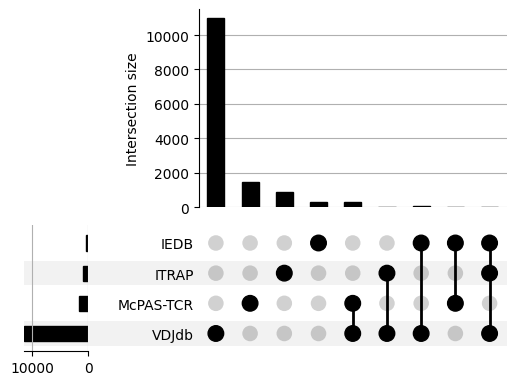

In [8]:
with warnings.catch_warnings():
    warnings.simplefilter(action='ignore', category=FutureWarning)
    upsetplot.UpSet(upsetplot.from_memberships(sequence_data['source']), subset_size='count').plot()

plt.show()

### Species

<Axes: ylabel='count'>

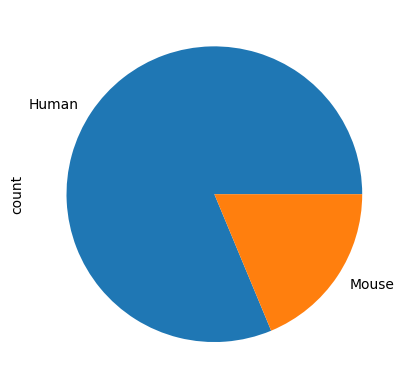

In [9]:
sequence_data['species'].value_counts().plot.pie()

### TCRs

In [10]:
sequence_data['collated_cdr_sequences'] = sequence_data.filter(regex='cdr[1-3]_alpha|beta').apply(
    '-'.join, axis='columns'
)

In [11]:
print('There are', len(sequence_data['collated_cdr_sequences'].unique()), 'unique TCRs')

print(len(sequence_data['cdr1_alpha'].unique()), 'unique CDR1as')
print(len(sequence_data['cdr2_alpha'].unique()), 'unique CDR2as')
print(len(sequence_data['cdr3_alpha'].unique()), 'unique CDR3as')
print(len(sequence_data['cdr1_beta'].unique()), 'unique CDR1bs')
print(len(sequence_data['cdr2_beta'].unique()), 'unique CDR2bs')
print(len(sequence_data['cdr3_beta'].unique()), 'unique CDR3bs')

There are 12295 unique TCRs
91 unique CDR1as
75 unique CDR2as
9020 unique CDR3as
55 unique CDR1bs
65 unique CDR2bs
9890 unique CDR3bs


#### CDR Lengths

In [12]:
cdr_lengths = sequence_data.filter(regex='cdr[1-3]_(alpha|beta)').map(len)
cdr_lengths = cdr_lengths.melt(value_vars=cdr_lengths.columns, value_name='length', var_name='cdr_type')

cdr_lengths['chain_type'] = cdr_lengths['cdr_type'].map(lambda cdr_type: cdr_type.split('_')[-1])
cdr_lengths['cdr_num'] = cdr_lengths['cdr_type'].map(lambda cdr_type: cdr_type.split('_')[0][-1]).apply(int)

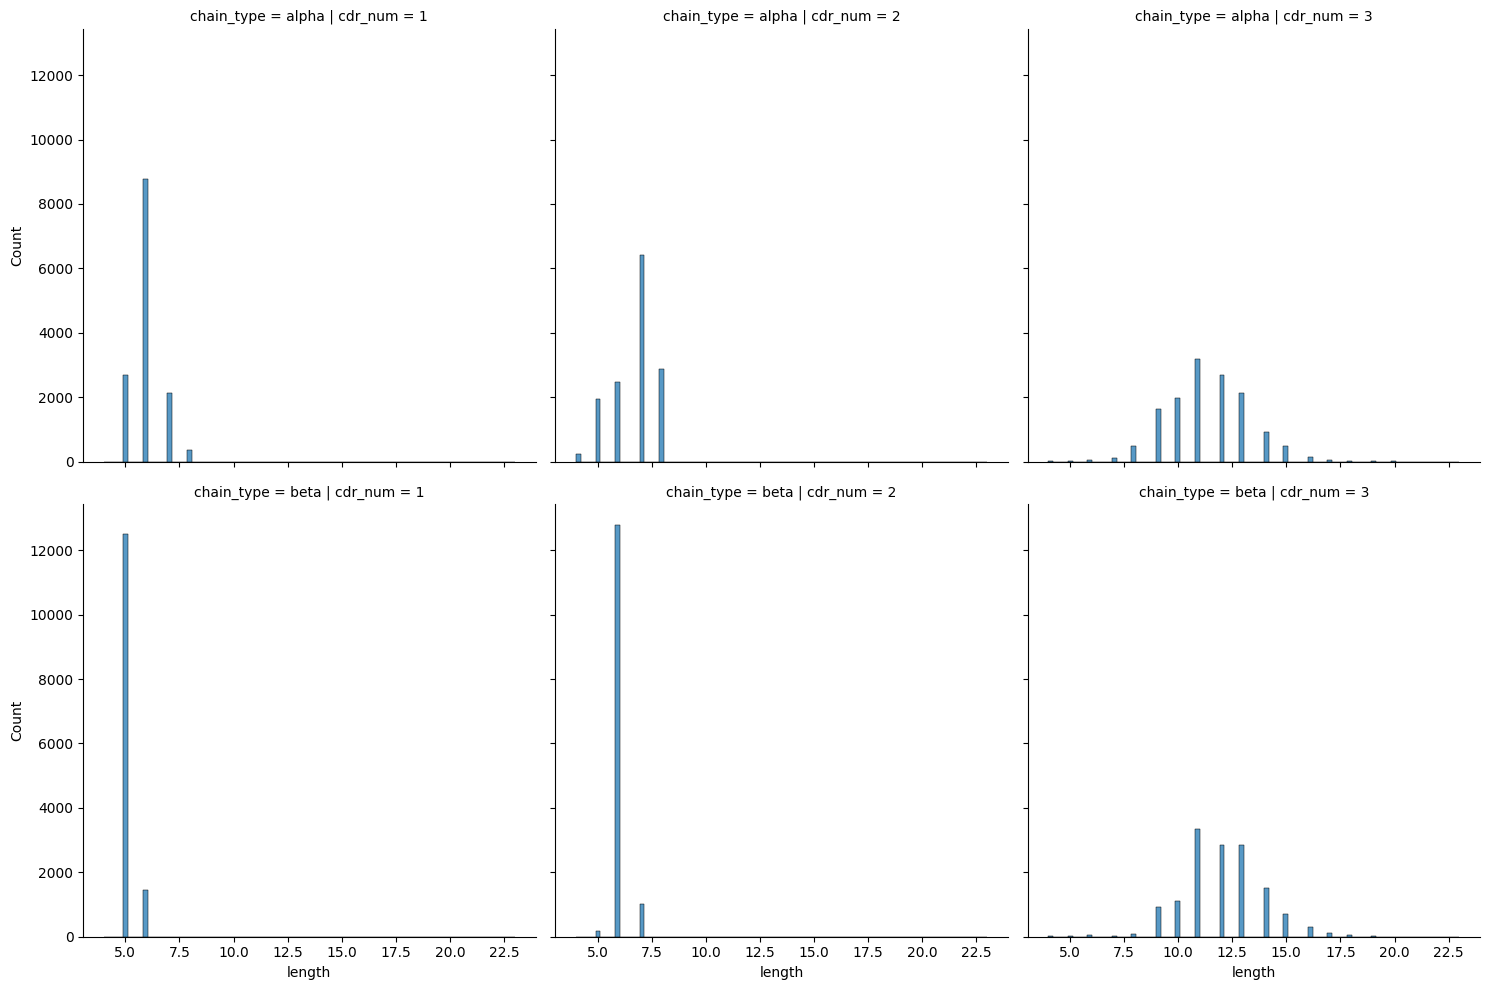

In [13]:
sns.displot(cdr_lengths, row='chain_type', col='cdr_num', x='length')

plt.show()

In [14]:
cdr_lengths.groupby(['chain_type', 'cdr_num'])['length'].describe()

count       mean       std  min   25%   50%   75%   max
chain_type cdr_num                                                           
alpha      1        13962.0   6.010887  0.669532  5.0   6.0   6.0   6.0   8.0
           2        13962.0   6.698109  1.002844  4.0   6.0   7.0   7.0   8.0
           3        13962.0  11.418851  1.919230  4.0  10.0  11.0  13.0  21.0
beta       1        13962.0   5.103352  0.304429  5.0   5.0   5.0   5.0   6.0
           2        13962.0   6.058874  0.284701  5.0   6.0   6.0   6.0   7.0
           3        13962.0  12.063458  1.855996  4.0  11.0  12.0  13.0  23.0

#### Gene usage and pairing

In [15]:
gene_codes = sequence_data[['v_alpha', 'j_alpha', 'v_beta', 'j_beta']].map(lambda code: code.split(';'))
gene_codes = gene_codes.explode('v_alpha').explode('j_alpha').explode('v_beta').explode('j_beta')

In [16]:
print('There are', len(gene_codes), 'unique gene combinations of the TCRs')

There are 18513 unique gene combinations of the TCRs


In [17]:
gene_codes = gene_codes.map(lambda code: code.split('*01')[0])

In [18]:
selection_df = pd.concat(
    [
        gene_codes[[source_gene_type, target_gene_type]]
        .value_counts()
        .reset_index()
        .rename({source_gene_type: 'source', target_gene_type: 'target'}, axis='columns')
        for source_gene_type, target_gene_type in itertools.pairwise(gene_codes.columns)
    ]
)

In [19]:
plot_df = selection_df.copy()

unique_source_target = list(np.unique(plot_df[['source', 'target']].to_numpy().flatten()))

mapping_dict = {k: v for v, k in enumerate(unique_source_target)}

plot_df['source'] = plot_df['source'].map(mapping_dict)
plot_df['target'] = plot_df['target'].map(mapping_dict)

fig = go.Figure(
    data=[
        go.Sankey(
            node={
                'pad': 20,
                'thickness': 30,
                'line': {'color': 'black', 'width': 0.5},
                'label': unique_source_target,
            },
            link={
                'source': plot_df['source'],
                'target': plot_df['target'],
                'value': plot_df['count'],
            },
        )
    ]
)

fig.update_layout(title_text='Sankey diagram of TCR gene usage', font_size=10, width=1400, height=900)
fig.show()

alpha-chain gene pairings


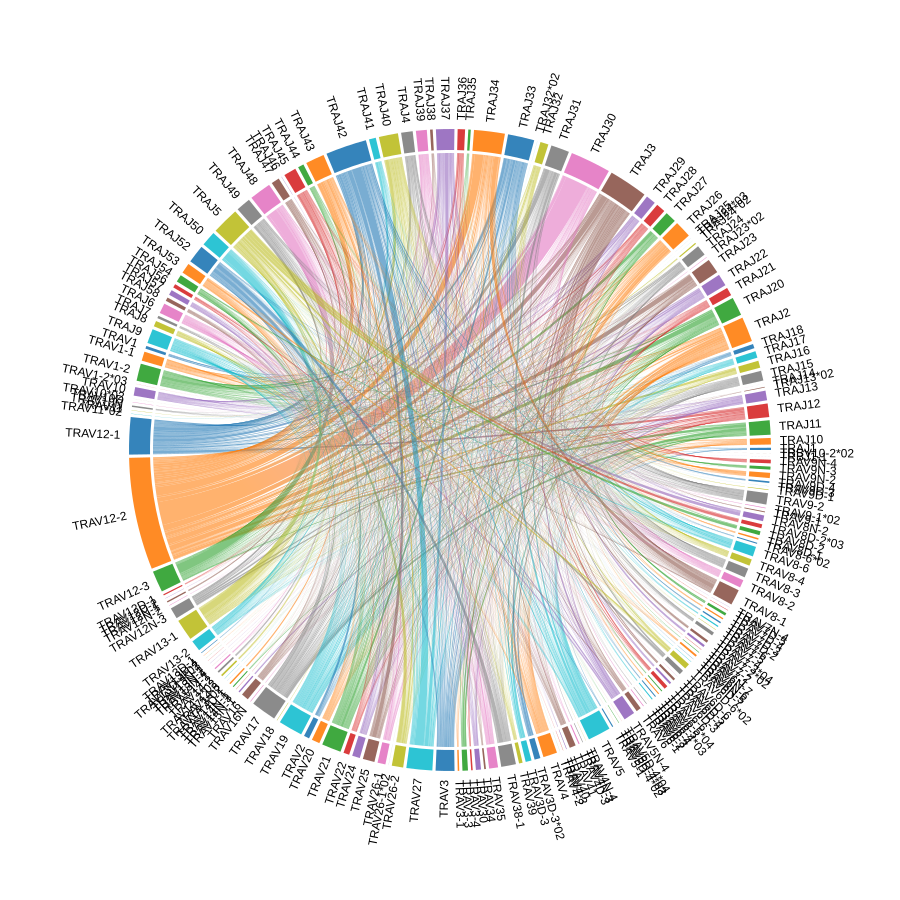

In [20]:
print('alpha-chain gene pairings')

counts = gene_codes.value_counts(['v_alpha', 'j_alpha'])
labels = sorted(
    np.concatenate([gene_codes['v_alpha'].dropna().unique(), gene_codes['j_alpha'].dropna().unique()]).tolist()
)

num_labels = len(labels)
adjacency_matrix = np.zeros((num_labels, num_labels), dtype=int)

for i in range(num_labels):
    for j in range(num_labels):
        try:
            adjacency_matrix[i, j] = counts[labels[i]][labels[j]]
        except KeyError:
            adjacency_matrix[i, j] = 0

adjacency_matrix = np.maximum(adjacency_matrix, adjacency_matrix.transpose())
fig = openchord.Chord(adjacency_matrix, labels)

fig.colormap = list(plt.rcParams['axes.prop_cycle'].by_key()['color'])

fig.radius = 300
fig.padding = 150
fig.font_size = 12

fig.show()

beta-chain gene pairings


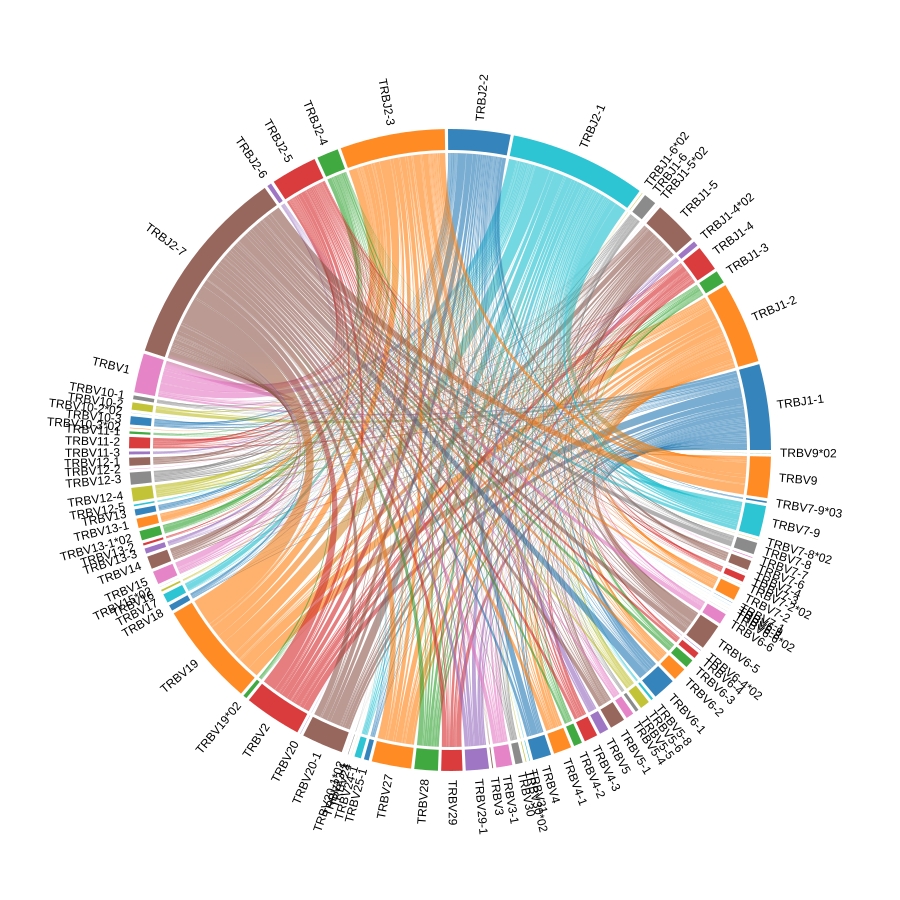

In [21]:
print('beta-chain gene pairings')
counts = gene_codes.value_counts(['v_beta', 'j_beta'])
labels = sorted(
    np.concatenate([gene_codes['v_beta'].dropna().unique(), gene_codes['j_beta'].dropna().unique()]).tolist()
)

num_labels = len(labels)
adjacency_matrix = np.zeros((num_labels, num_labels), dtype=int)

for i in range(num_labels):
    for j in range(num_labels):
        try:
            adjacency_matrix[i, j] = counts[labels[i]][labels[j]]
        except KeyError:
            adjacency_matrix[i, j] = 0

adjacency_matrix = np.maximum(adjacency_matrix, adjacency_matrix.transpose())
fig = openchord.Chord(adjacency_matrix, labels)

fig.colormap = list(plt.rcParams['axes.prop_cycle'].by_key()['color'])

fig.radius = 300
fig.padding = 150
fig.font_size = 12

fig.show()

<Axes: title={'center': 'V-gene pairings between chains'}, xlabel='v_beta', ylabel='v_alpha'>

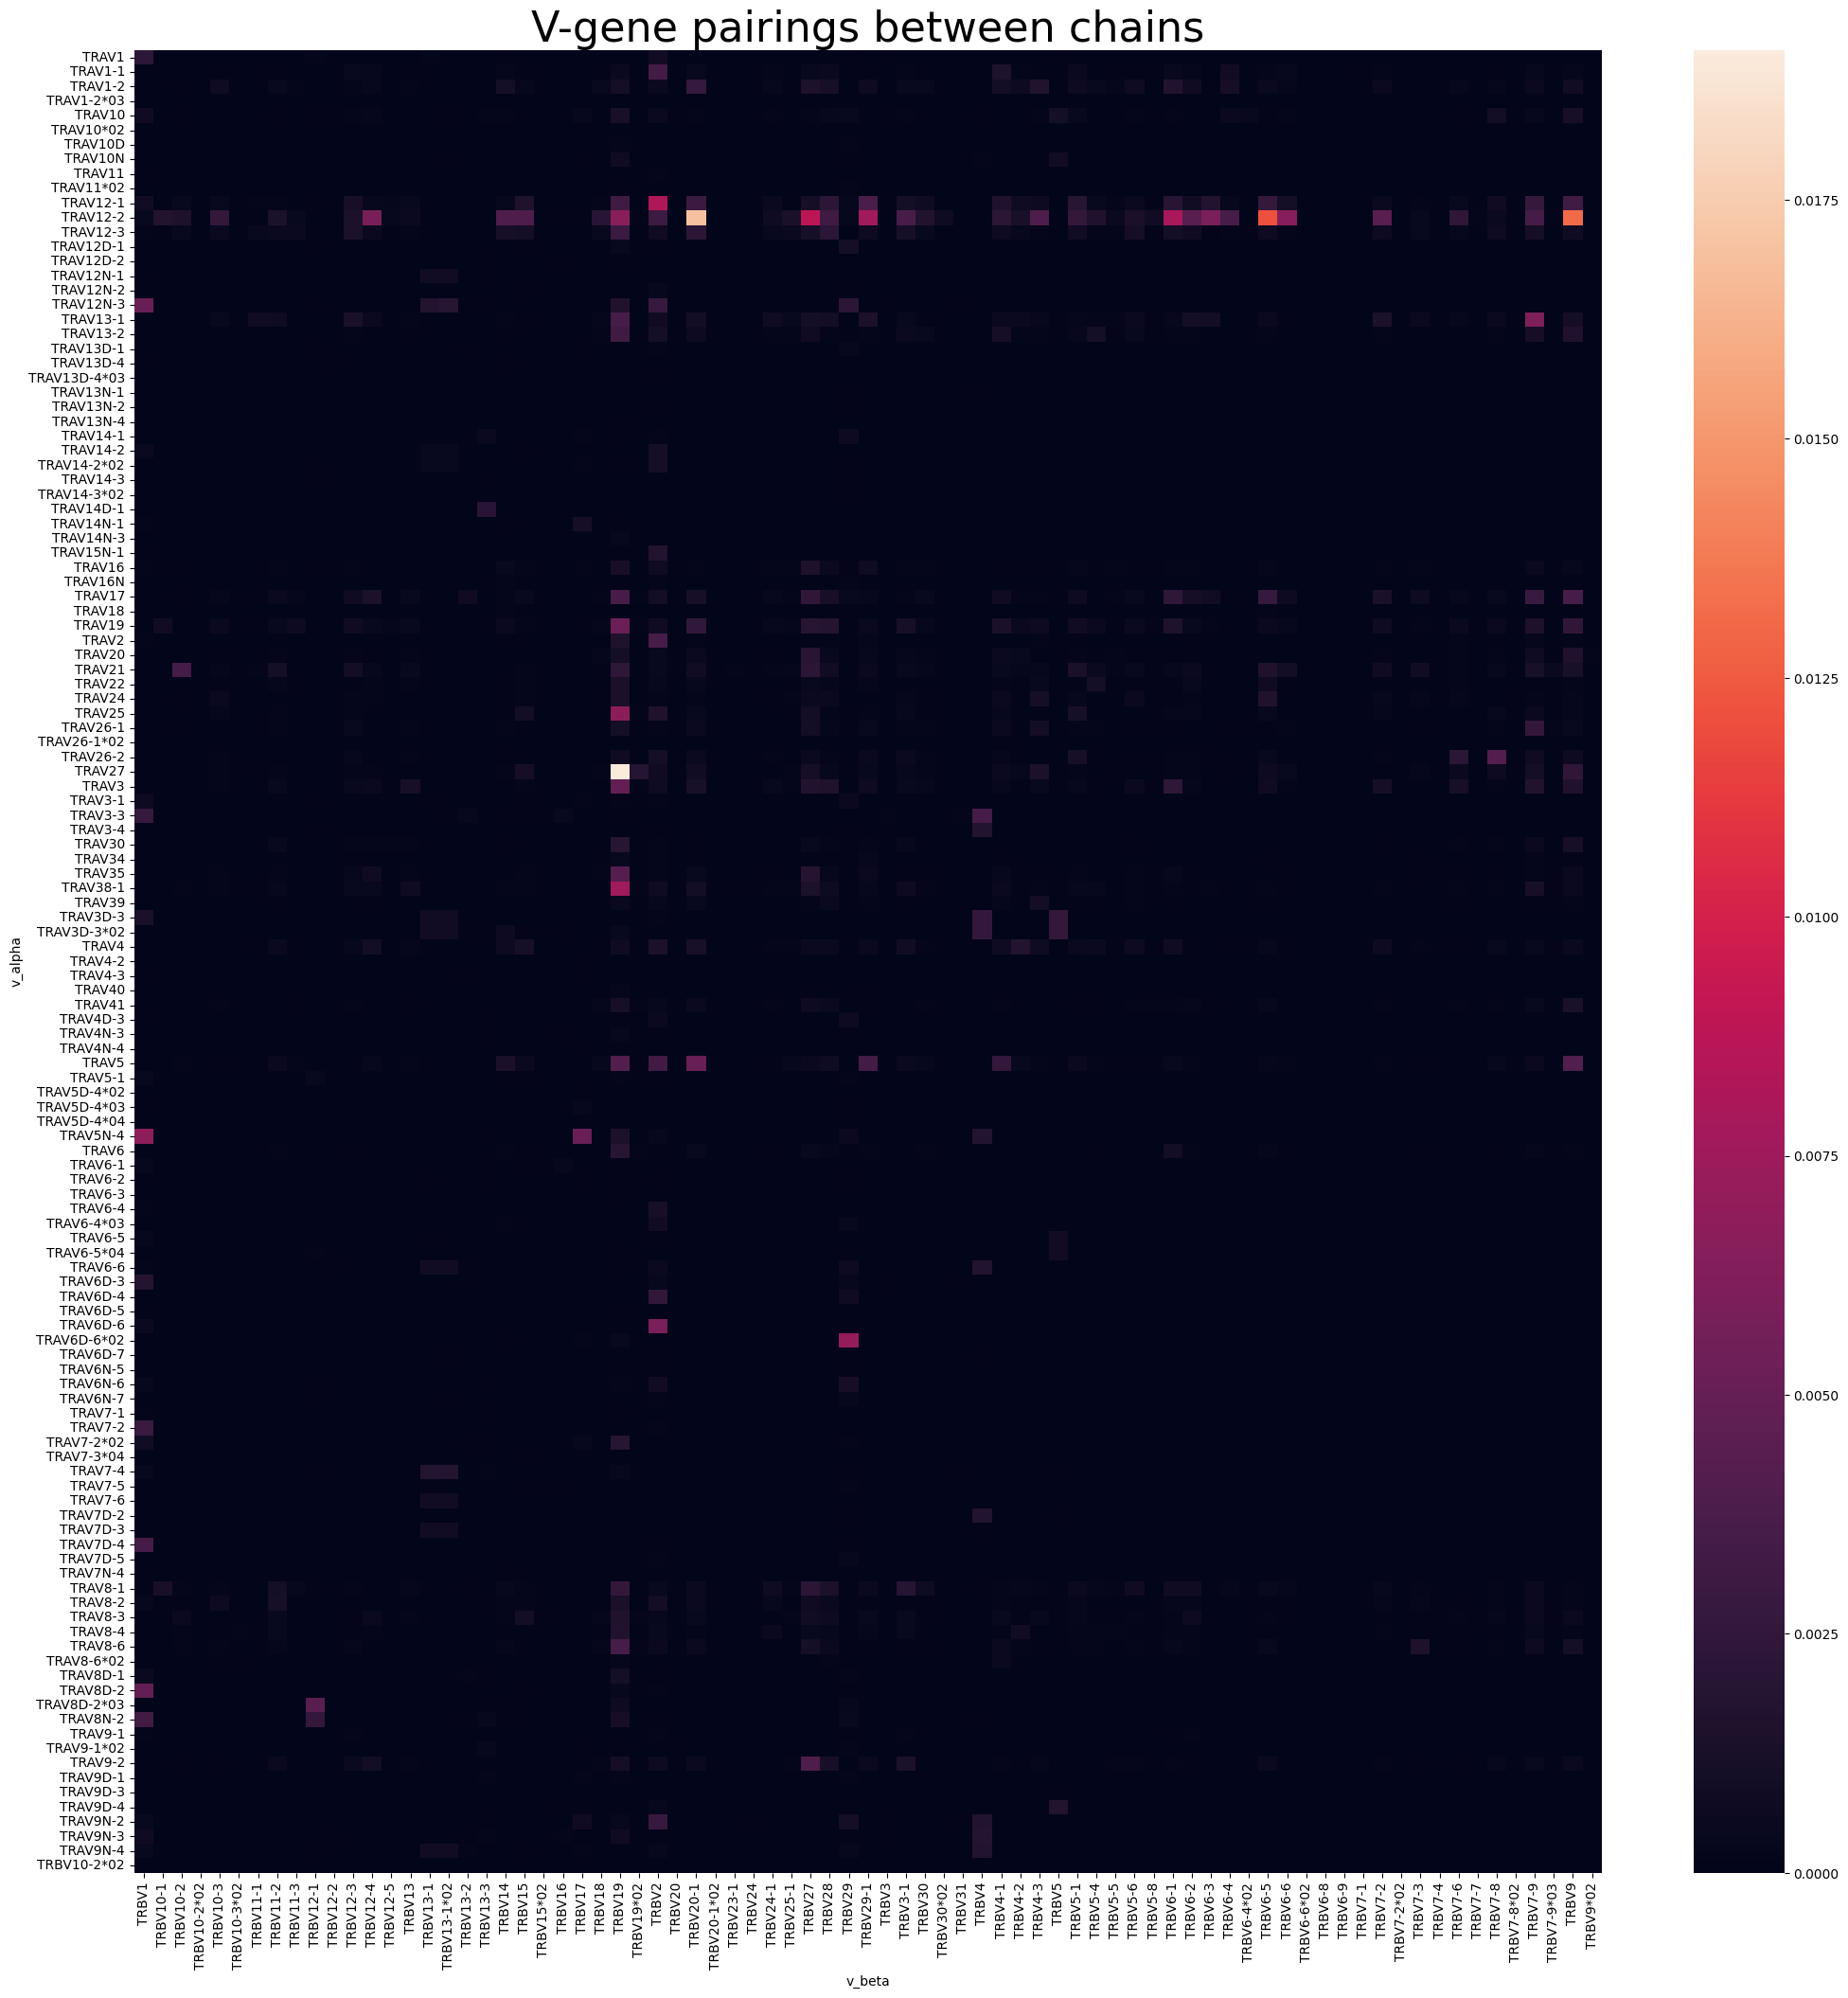

In [22]:
plt.figure(figsize=(25, 25))
plt.title('V-gene pairings between chains', fontsize=32)

sns.heatmap(
    gene_codes.value_counts(['v_alpha', 'v_beta'], normalize=True)
    .to_frame()
    .reset_index()
    .pivot_table(index='v_alpha', columns='v_beta', values='proportion')
    .fillna(0)
)

### Peptides

In [23]:
print('There are', len(sequence_data['peptide'].unique()), 'unique peptides')

There are 1033 unique peptides


In [24]:
sequence_data['peptide_length'] = sequence_data['peptide'].str.len()

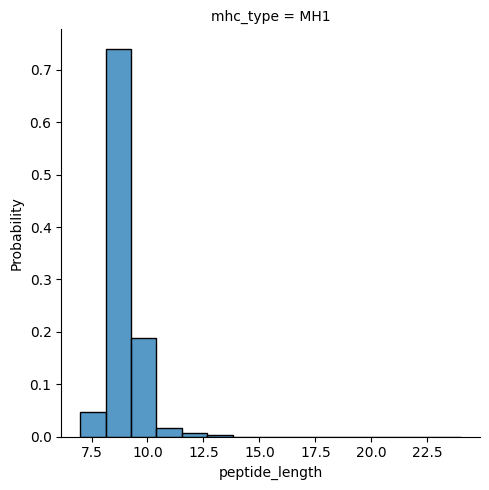

In [25]:
sns.displot(
    sequence_data,
    x='peptide_length',
    col='mhc_type',
    stat='probability',
    common_norm=False,
)

plt.show()

In [26]:
sequence_data.groupby('mhc_type')['peptide_length'].describe()

,count,mean,std,min,25%,50%,75%,max
mhc_type,,,,,,,,
MH1,13962.0,9.20434,0.616141,7.0,9.0,9.0,9.0,24.0


In [27]:
peptide_sequences = sequence_data['peptide'].unique()

distance_matrix = np.zeros((peptide_sequences.shape[0], peptide_sequences.shape[0]), dtype=int)

for i in range(peptide_sequences.shape[0]):
    for j in range(i + 1, peptide_sequences.shape[0]):
        distance_matrix[i, j] = damerau_levenshtein_distance(peptide_sequences[i], peptide_sequences[j])

distance_matrix = np.maximum(distance_matrix, distance_matrix.T)

print(
    f'The average levenshtein distance between all peptide sequences is {np.average(distance_matrix):.2f} edits',
    f'with an standard deviation of {np.std(distance_matrix):.2f} edits.',
)

The average levenshtein distance between all peptide sequences is 8.43 edits with an standard deviation of 1.31 edits.


In [28]:
CUTOFF_PERCENT = 70

sequence_lengths = np.array([len(seq) for seq in peptide_sequences])
grid1, grid2 = np.meshgrid(sequence_lengths, sequence_lengths)

max_lengths = np.maximum(grid1, grid2)
sequence_percent_identities = ((max_lengths - distance_matrix) / max_lengths) * 100

similar_peptides = sequence_percent_identities > CUTOFF_PERCENT

In [29]:
G = nx.Graph()
G.add_nodes_from(range(peptide_sequences.shape[0]))

for i in range(1, peptide_sequences.shape[0]):
    for j in range(i + 1, peptide_sequences.shape[0]):
        if similar_peptides[i, j]:
            G.add_edge(i, j, weight=sequence_percent_identities[i, j] / 100)

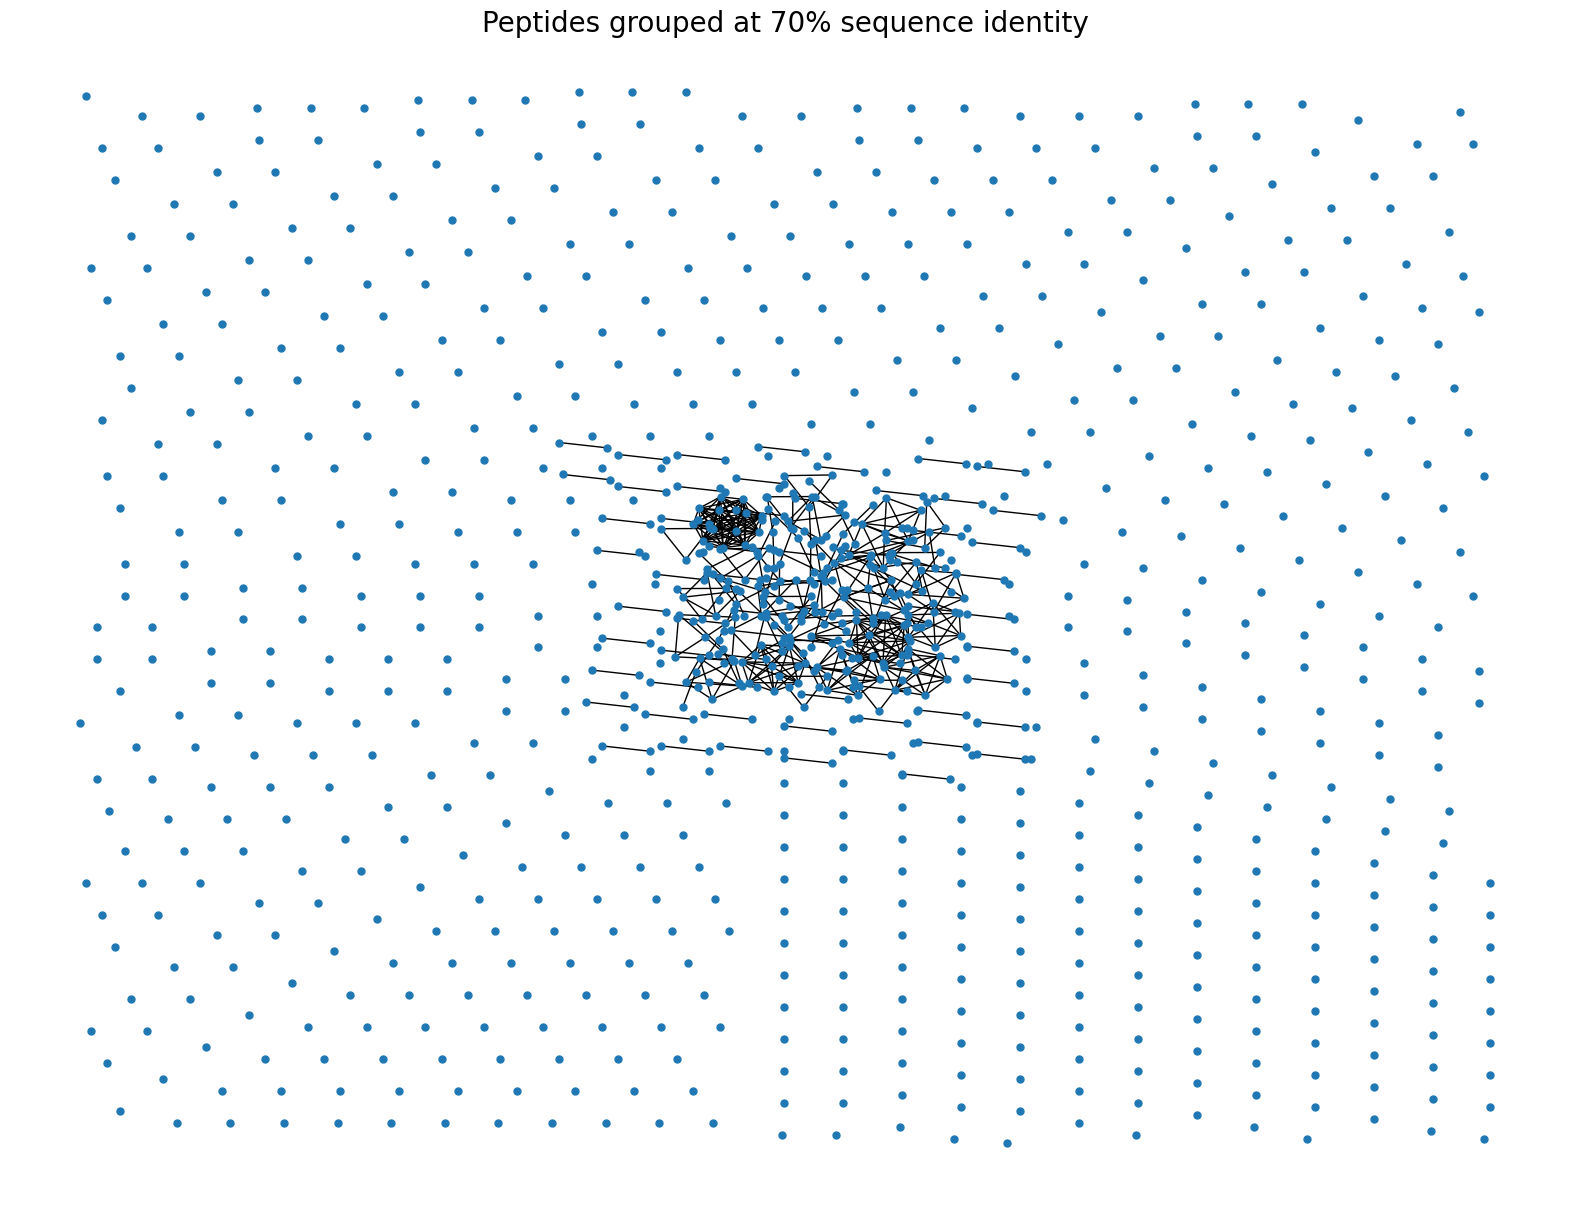

In [30]:
plt.figure(figsize=(20, 15))
plt.title('Peptides grouped at 70% sequence identity', fontsize=20)

nx.draw(
    G,
    node_size=25,
    pos=nx.drawing.nx_agraph.graphviz_layout(G, prog='neato'),
)

### MHCs

<Axes: ylabel='count'>

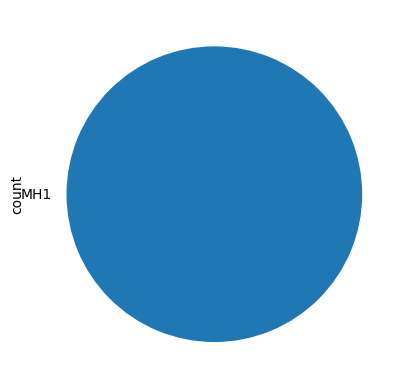

In [31]:
sequence_data['mhc_type'].value_counts().plot.pie()

<Axes: xlabel='mhc1'>

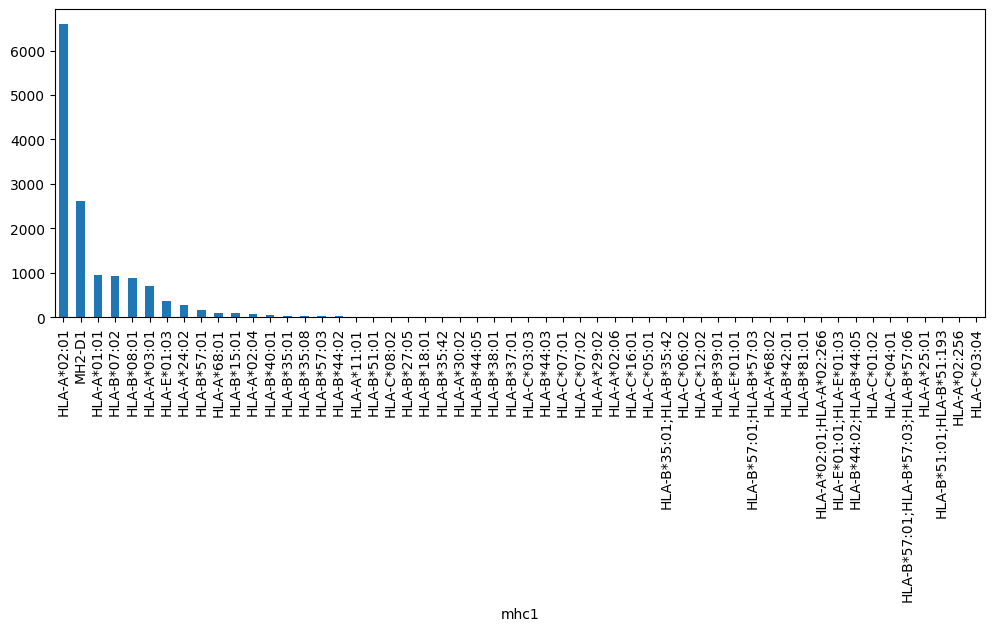

In [32]:
sequence_data.query("mhc_type == 'MH1'")['mhc1'].value_counts().plot.bar(figsize=(12, 4))

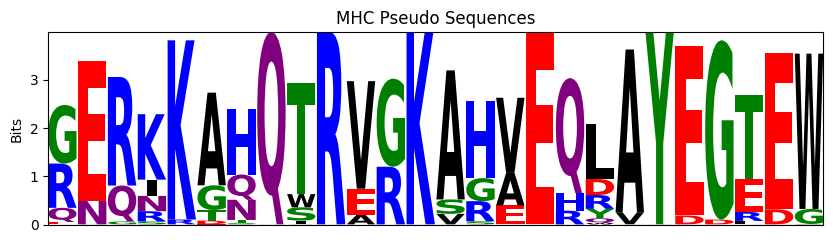

In [33]:
probs = logomaker.alignment_to_matrix(sequence_data['mhc_pseudo'], to_type='information')
logomaker.Logo(probs, color_scheme='chemistry')

plt.title('MHC Pseudo Sequences')
plt.ylabel('Bits')
plt.xticks([])

plt.show()

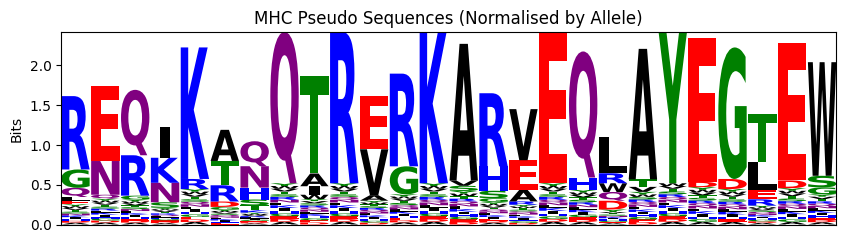

In [34]:
probs = logomaker.alignment_to_matrix(
    sequence_data.drop_duplicates(['mhc1', 'mhc2'])['mhc_pseudo'],
    to_type='information',
)
logomaker.Logo(probs, color_scheme='chemistry')

plt.title('MHC Pseudo Sequences (Normalised by Allele)')
plt.ylabel('Bits')
plt.xticks([])

plt.show()

### Interactions between TCRs and pMHCs

In [35]:
sequence_data['pmhc'] = (
    sequence_data[['peptide', 'mhc1', 'mhc2']].replace('B2M', '').apply('-'.join, axis='columns').str.rstrip('-')
)

In [36]:
sequence_data.groupby('collated_cdr_sequences').size().describe()

count    12295.000000
mean         1.135584
std          0.607353
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         38.000000
dtype: float64

In [37]:
sequence_data.groupby('peptide').size().describe()

count    1033.000000
mean       13.515973
std        90.529515
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max      2107.000000
dtype: float64

Graph with 13360 nodes and 12655 edges


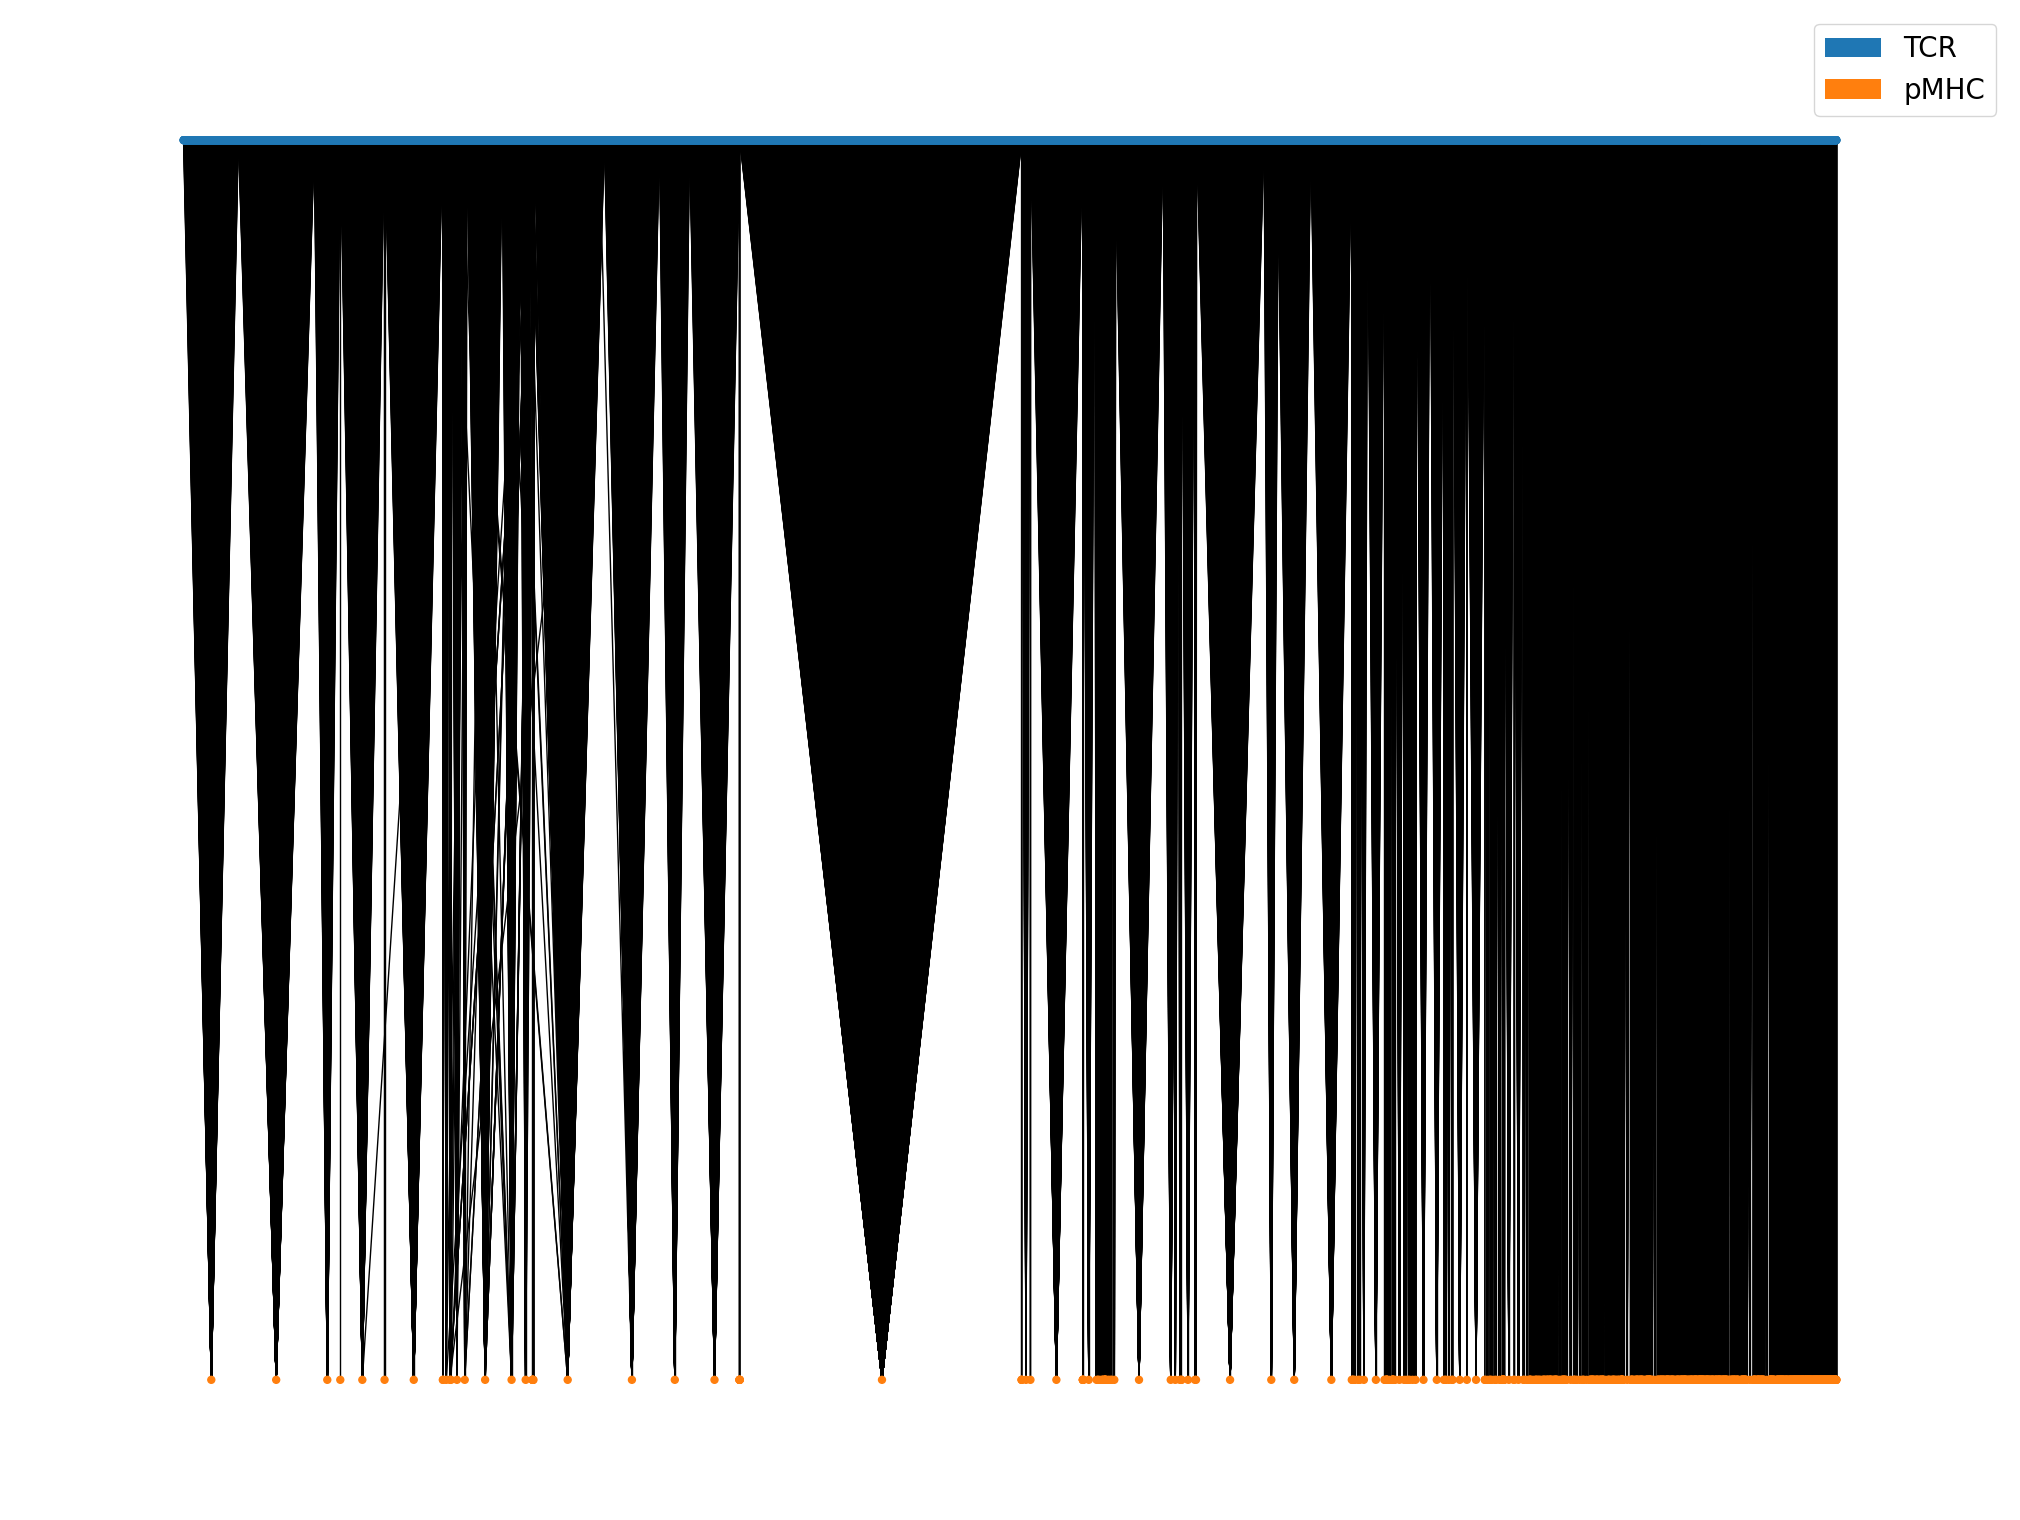

In [38]:
graph = nx.Graph()

graph.add_nodes_from([(tcr, {'color': 'tab:blue'}) for tcr in sequence_data['collated_cdr_sequences'].unique()])
graph.add_nodes_from([(pmhc, {'color': 'tab:orange'}) for pmhc in sequence_data['pmhc'].unique()])

graph.add_edges_from(sequence_data[['collated_cdr_sequences', 'pmhc']].apply(tuple, axis=1).tolist())

print(graph)

plt.figure(figsize=(20, 15))

with warnings.catch_warnings():
    warnings.simplefilter(action='ignore', category=RuntimeWarning)
    nx.draw(
        graph,
        node_size=25,
        node_color=[graph.nodes[node]['color'] for node in graph.nodes()],
        pos=nx.drawing.nx_agraph.graphviz_layout(graph, prog='dot', args='-Granksep=5 -Gnodesep=0.8'),
    )
    legend_elements = [
        Patch(facecolor='tab:blue', label='TCR'),
        Patch(facecolor='tab:orange', label='pMHC'),
    ]


plt.legend(handles=legend_elements, loc='upper right', fontsize=20)

plt.show()

There is a strong many-to-1 bias for the TCR:pMHC interactions but there are a few examples of TCRs binding different peptides.